# Pengelompokan Tingkat Keparahan Luka Diabetes dari Citra Kaki Menggunakan CNN dan K-Means


## Setup Google Colab

Cell di bawah hanya aktif jika notebook ini dibuka di Google Colab. Jika dijalankan di lokal, cell ini tidak akan melakukan apa-apa.

In [ ]:
import importlib.util

IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB:
    from pathlib import Path

    REPO_URL = "https://github.com/musyaree/fp-kcv.git"
    REPO_DIR = Path("/content/fp-kcv")

    if not REPO_DIR.exists():
        !git clone {REPO_URL} {REPO_DIR}

    %cd {REPO_DIR}/notebook

    raw_dir = REPO_DIR / "data" / "raw"
    if not raw_dir.exists() or not any(raw_dir.iterdir()):
        !python ../download_data.py
else:
    print("Bukan di Colab, lewati setup Colab.")

## Tahap 0. Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from data_prep import eda, preprocess, split_dataset, subset_dataset

## Tahap 1. Pengumpulan dan Eksplorasi Dataset (EDA)

### 1.1 Mengunduh Dataset & Mengambil Subset

Dataset, Diabetic Foot Ulcer, diunduh terpisah dengan menjalankan `download_data.py`. Kita mengambil subset seimbang, yaitu 250 Abnormal dan 250 Normal, dari folder `Patches/` yang sudah berlabel.

In [2]:
subset_dataset.main(argv=[])

Abnormal: 250 gambar disalin ke data/processed/subset/Abnormal
Normal: 250 gambar disalin ke data/processed/subset/Normal

Total: 500 gambar. Manifest disimpan di data/processed/subset/manifest.csv


### 1.2 Eksplorasi Data (EDA)

Cek jumlah gambar per kategori, lihat statistik ukurannya, lalu tampilkan beberapa sampel visual agar variasi data terlihat.

=== EDA Summary — Subset DFU ===

Jumlah gambar per kategori:
  Abnormal: 250
  Normal: 250
  Total: 500

Statistik ukuran gambar:
  Width  : min=220, max=330
  Height : min=220, max=330
  Ukuran unik: [(220, 220), (224, 224), (224, 244), (227, 227), (283, 280), (304, 294), (310, 316), (330, 330)]

Sampel visual disimpan di: outputs/eda_sample_grid.png
Sumber dataset: Kaggle Diabetic Foot Ulcer (DFU) Dataset (Laith Jj)
https://www.kaggle.com/datasets/laithjj/diabetic-foot-ulcer-dfu

Grid sampel disimpan di: outputs/eda_sample_grid.png


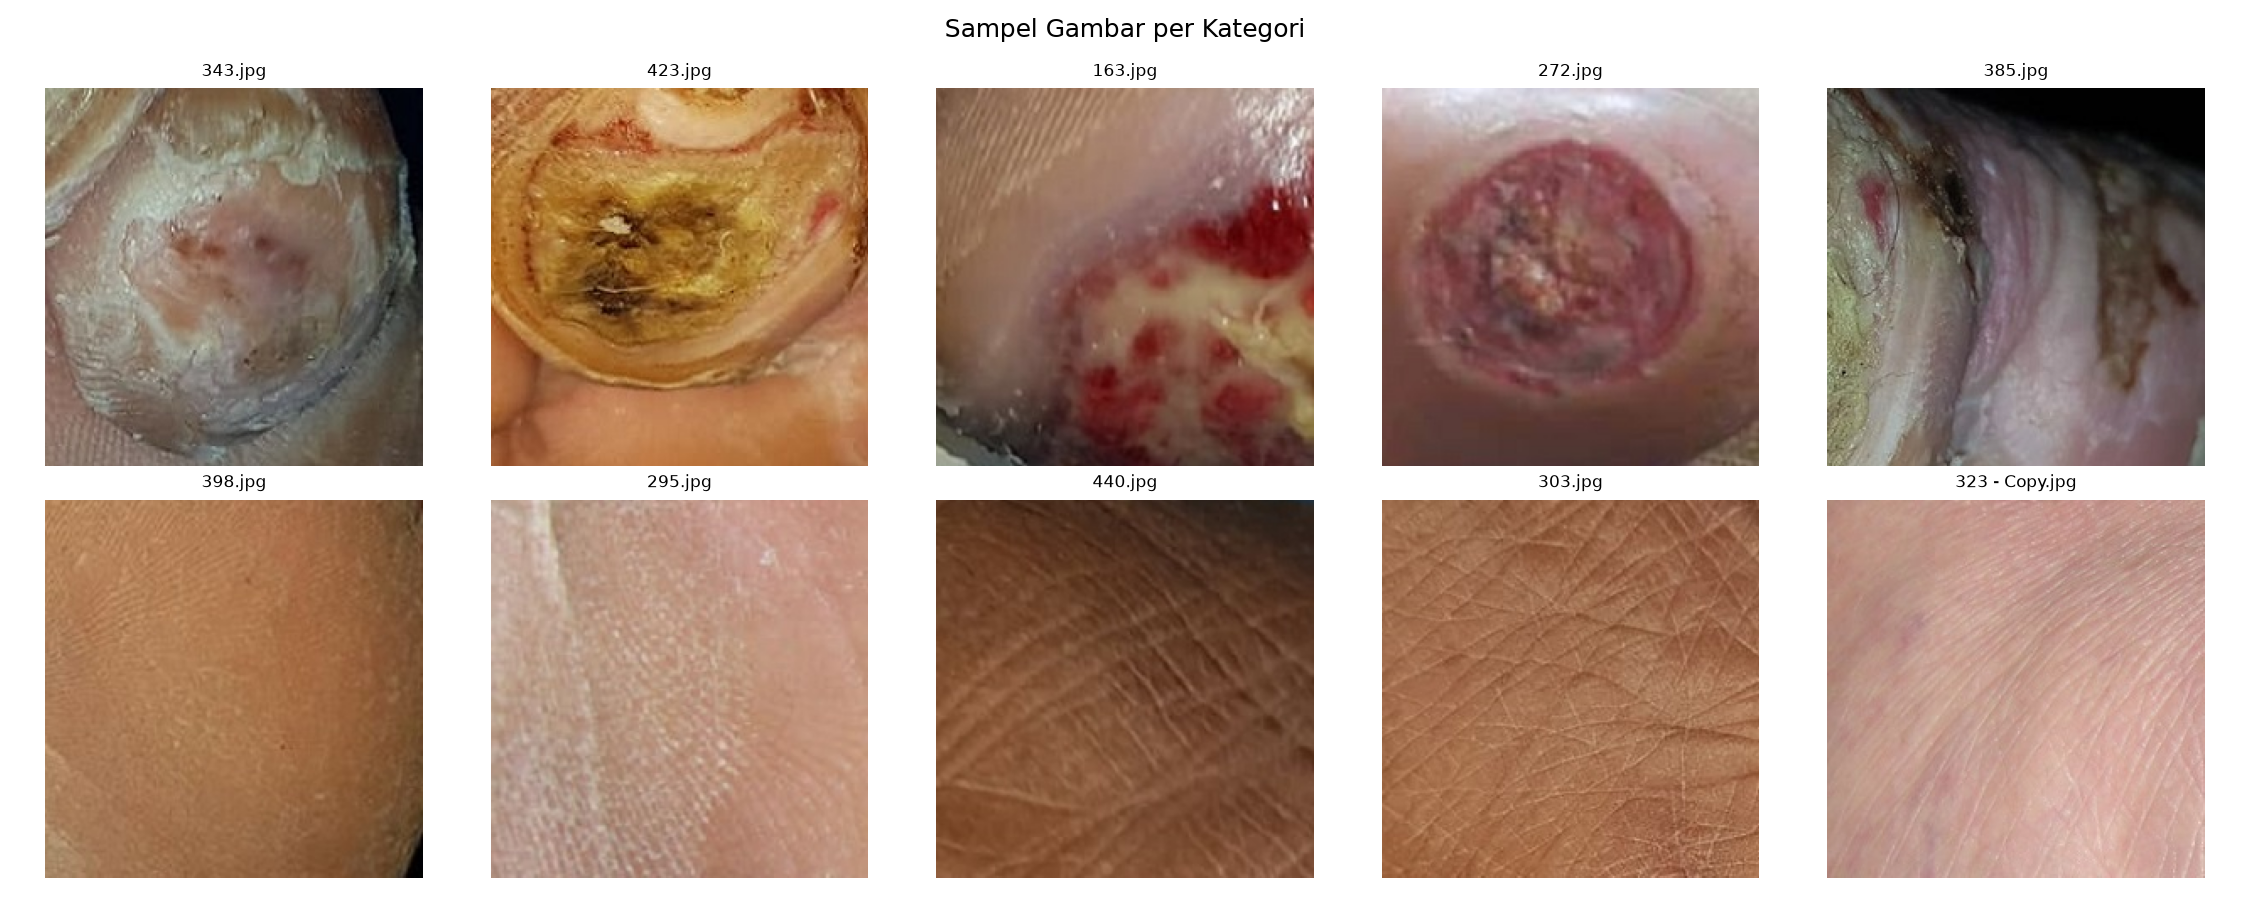

In [ ]:
from IPython.display import Image, display

eda.main()
display(Image(filename=str(eda.OUTPUTS_DIR / "eda_sample_grid.png")))

## Tahap 2. Pra-pemrosesan Citra

### 2.1 Standardisasi Ukuran, Format, dan Normalisasi

Pre-Process CNN: resize semua gambar ke ukuran 224x224, lalu normalisasi memakai mean/std ImageNet.
Pre-Process Handcrafted: Konversi ke HSV menggunakan skala 0-1.

In [5]:
preprocess.main()

Selesai preprocessing.


### 2.2 Split Data Latih dan Data Uji

Split 80:20 per kategori, supaya proporsi Normal dan Abnormal tetap seimbang di kedua sisi.

In [6]:
split_dataset.main()

Selesai split data.


In [7]:
import csv

import pandas as pd

with open(split_dataset.MANIFEST_PATH, newline="", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

df = pd.DataFrame(rows)
pd.crosstab(df["label"], df["split"])

split,test,train
label,,
Abnormal,50,200
Normal,50,200
